# 03 · LSTM & GRU — Fixing the Memory Problem of Vanilla RNNs

In notebooks 01–02 we used the **vanilla RNN**. It has a famous flaw: it **forgets**. On long
sequences it cannot connect a clue at the start to a decision at the end, because the training
signal (the gradient) **vanishes** as it travels back through many time steps.

This notebook:

1. Shows the **vanishing-gradient problem** concretely, with a tiny experiment you can watch.
2. Designs a **"long-memory" task** that a vanilla RNN *cannot* solve but LSTM/GRU can.
3. Explains the **LSTM** (cell state + forget/input/output gates) and the **GRU** (reset/update
   gates) in plain language.
4. Runs a **head-to-head comparison**: RNN vs LSTM vs GRU as the sequence gets longer.
5. Gives you a practical **"which one should I use?"** guide.

> 💡 A one-line summary you can keep: **LSTM and GRU add *gates* — little learned valves that
> decide what to keep, what to forget, and what to output — plus a protected "highway" for
> information to flow across many steps without vanishing.**

In [16]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. Why vanilla RNNs forget: the vanishing gradient

When we train with Back-Prop Through Time, the gradient at an early step gets multiplied by the
recurrent weight (and the tanh slope) **once for every step it travels back**. Multiplying many
numbers that are each **< 1** drives the product toward **zero** — the gradient *vanishes*, so
early steps receive almost no learning signal. (If the numbers are **> 1**, the opposite happens:
gradients *explode*.)

Let's demonstrate the shrinking with a toy: repeatedly multiply by a typical recurrent factor and
watch how fast the influence dies over time steps.

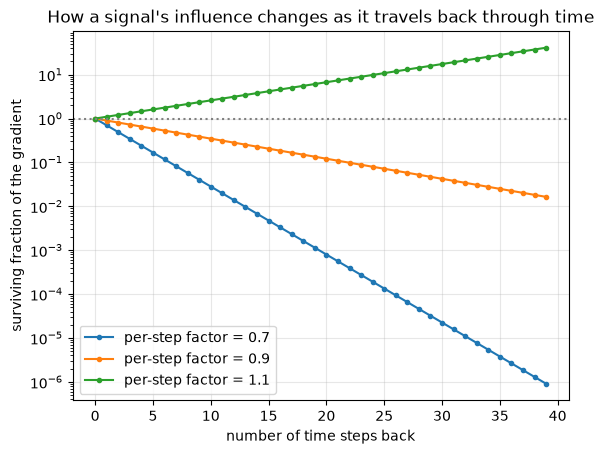

factor 0.7 after 30 steps: 2.3e-05  -> essentially ZERO (vanished)
factor 1.1 after 30 steps: 17.45  -> huge (exploded)

Only a factor of EXACTLY 1 keeps a signal alive over long distances — and vanilla RNNs
cannot hold that balance. LSTM/GRU engineer a path that stays near 1 on purpose.


In [17]:
# Suppose the "per-step" gradient factor is around 0.7 (weight * tanh-slope). How much of the
# signal survives after k steps? It's 0.7**k.
steps = np.arange(0, 40)
for factor in [0.7, 0.9, 1.1]:
    plt.plot(steps, factor ** steps, marker=".", label=f"per-step factor = {factor}")
plt.axhline(1.0, color="gray", ls=":")
plt.title("How a signal's influence changes as it travels back through time")
plt.xlabel("number of time steps back"); plt.ylabel("surviving fraction of the gradient")
plt.yscale("log"); plt.legend(); plt.grid(alpha=0.3); plt.show()

print("factor 0.7 after 30 steps:", round(0.7**30, 6), " -> essentially ZERO (vanished)")
print("factor 1.1 after 30 steps:", round(1.1**30, 2),   " -> huge (exploded)")
print("\nOnly a factor of EXACTLY 1 keeps a signal alive over long distances — and vanilla RNNs")
print("cannot hold that balance. LSTM/GRU engineer a path that stays near 1 on purpose.")

## 2. A task designed to need long memory

We build a classic **"remember one bit"** task — but one that genuinely requires *protecting* a
memory against interference (not just holding a big value through silence, which even a vanilla RNN
does easily):

- Every step has **two features**: a `value` and a `cue` flag.
- At **step 0** the `cue` is 1 and the `value` is the bit to remember (**+1 or −1**).
- Every **later** step is a **large random distractor** (`cue = 0`, `value` = loud noise) that
  actively tries to overwrite whatever the network is holding.
- The model must output the remembered bit **at the last step**.

Because the distractors are as big as the signal, the network can't coast — it must **actively
protect** the stored bit. That is exactly the job gates are built for. As the sequence grows, a
vanilla RNN gets its memory overwritten (accuracy → 50%), while LSTM/GRU gate the noise out.

In [18]:
DISTRACTOR = 4.0   # magnitude of the interfering noise; as loud as this makes memory hard to hold

def make_memory_task(n_samples, length):
    '''Two features per step: [value, cue].
       Step 0 holds the bit to remember (cue=1); every later step is a LOUD distractor (cue=0).'''
    X = np.zeros((n_samples, length, 2), dtype=np.float32)
    X[:, :, 0] = DISTRACTOR * np.random.randn(n_samples, length)   # loud distractors everywhere
    bit = np.where(np.random.rand(n_samples) > 0.5, 1.0, -1.0).astype(np.float32)
    X[:, 0, 0] = bit                                               # the value to remember...
    X[:, 0, 1] = 1.0                                               # ...flagged by the cue at step 0
    y = (bit > 0).astype(np.int64)
    return torch.tensor(X), torch.tensor(y)

Xdemo, ydemo = make_memory_task(3, length=6)
print("Three samples (length 6). Row 'value' = feature 0, row 'cue' = feature 1.\n")
for i in range(3):
    vals = np.round(Xdemo[i, :, 0].numpy(), 1).tolist()
    cues = Xdemo[i, :, 1].numpy().astype(int).tolist()
    print(f"  label={ydemo[i].item()}   value={vals}")
    print(f"             cue  ={cues}")
print("\nOnly the value under cue=1 (step 0) is the label; the rest is loud noise to be ignored.")

Three samples (length 6). Row 'value' = feature 0, row 'cue' = feature 1.

  label=0   value=[-1.0, 1.600000023841858, 3.9000000953674316, 9.0, 7.5, -3.9000000953674316]
             cue  =[1, 0, 0, 0, 0, 0]
  label=1   value=[1.0, -0.6000000238418579, -0.4000000059604645, 1.600000023841858, 0.6000000238418579, 5.800000190734863]
             cue  =[1, 0, 0, 0, 0, 0]
  label=0   value=[-1.0, 0.5, 1.7999999523162842, 1.2999999523162842, 6.0, -0.800000011920929]
             cue  =[1, 0, 0, 0, 0, 0]

Only the value under cue=1 (step 0) is the label; the rest is loud noise to be ignored.


## 3. LSTM in plain language — the cell state and three gates

An **LSTM** (Long Short-Term Memory) keeps **two** memories:

- the **hidden state `h`** (the short-term / output memory, like the vanilla RNN), and
- the **cell state `C`** — a *protected conveyor belt* that runs straight through time with only
  minor, gentle edits. This belt is the "highway" that keeps gradients from vanishing.

Three **gates** (each a small learned neural net outputting values in 0…1, like valves) control
the belt:

| Gate | Question it answers | Effect |
|---|---|---|
| **Forget gate** $f_t$ | "What should I erase from the belt?" | multiplies old cell state (0 = wipe, 1 = keep) |
| **Input gate** $i_t$ | "What new info should I write?" | how much of the candidate update to add |
| **Output gate** $o_t$ | "What should I expose as this step's output?" | filters the cell into the hidden state |

The equations (for reference — you rarely write them by hand):

$$
\begin{aligned}
f_t &= \sigma(W_f[h_{t-1},x_t]+b_f) & \text{(forget)}\\
i_t &= \sigma(W_i[h_{t-1},x_t]+b_i) & \text{(input)}\\
\tilde{C}_t &= \tanh(W_C[h_{t-1},x_t]+b_C) & \text{(candidate)}\\
C_t &= f_t \odot C_{t-1} + i_t \odot \tilde{C}_t & \text{(update the belt)}\\
o_t &= \sigma(W_o[h_{t-1},x_t]+b_o) & \text{(output)}\\
h_t &= o_t \odot \tanh(C_t) & \text{(new hidden state)}
\end{aligned}
$$

The key line is $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$: when the forget gate is near
**1** and the input gate near **0**, the belt **passes information through unchanged** — that is
the long-memory highway.

### Why the cell state's path doesn't shrink

The LSTM's cell-state update is additive, not a repeated squash:

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Differentiate the belt with respect to the previous belt:

$$\frac{\partial C_t}{\partial C_{t-1}} = f_t \quad(\text{elementwise, the forget gate})$$

That's the whole trick. Going one step back, the gradient is just multiplied by the forget gate $f_t$ — an elementwise number the network controls — instead of passing through a matrix multiply and a saturating tanh. When the LSTM wants to remember something, it drives $f_t$ ≈ 1, so:

$$\frac{\partial C_t}{\partial C_{t-k}} \approx f_t \cdot f_{t-1} \cdots f_{t-k+1} \approx 1$$

— a product of numbers near 1, which stays near 1 over many steps. The gradient flows all the way back intact. That's exactly what "the highway that keeps gradients from vanishing" means.

The original 1997 LSTM paper calls this the Constant Error Carousel (CEC): the cell state is engineered precisely so that error (i.e. gradient) is carried backward with roughly constant scale. So it's not exempt from backprop — it's the mechanism that makes backprop work over long distances.

## 4. GRU in plain language — same idea, fewer parts

The **GRU** (Gated Recurrent Unit) is a **streamlined LSTM**: it merges the cell and hidden state
into one, and uses just **two** gates. Fewer parameters → often trains faster and needs less data,
with accuracy usually **on par** with the LSTM.

| Gate | Role |
|---|---|
| **Update gate** $z_t$ | blends old state vs. new candidate (does the job of LSTM's forget+input together) |
| **Reset gate** $r_t$ | decides how much past state to use when forming the new candidate |

$$
\begin{aligned}
z_t &= \sigma(W_z[h_{t-1},x_t]) & \text{(update)}\\
r_t &= \sigma(W_r[h_{t-1},x_t]) & \text{(reset)}\\
\tilde{h}_t &= \tanh(W[r_t \odot h_{t-1},\, x_t]) & \text{(candidate)}\\
h_t &= (1-z_t)\odot h_{t-1} + z_t \odot \tilde{h}_t & \text{(blend old \& new)}
\end{aligned}
$$

Notice the blend $h_t=(1-z_t)h_{t-1}+z_t\tilde h_t$: if $z_t\approx 0$ the state is **copied
forward untouched** — the GRU's version of the memory highway.

> ✅ **Great news for you as a practitioner:** in PyTorch, swapping between them is a *one-word*
> change — `nn.RNN`, `nn.LSTM`, `nn.GRU` share almost the same interface. Let's exploit that.

### Can we approximate one model to the other? 

1. GRU → vanilla RNN — ✅ yes, exactly (in the saturating limit)
Recall PyTorch's GRU:
$$r_t=\sigma(\cdot),\quad z_t=\sigma(\cdot),\quad n_t=\tanh(W_{in}x_t + r_t\odot(W_{hn}h_{t-1}) + b),\quad h_t=(1-z_t)\odot h_{t-1} + z_t\odot n_t$$

Force both gates open:

z → 1: zero the update-gate weights (W_iz=W_hz=0), set its bias large positive.
r → 1: zero the reset-gate weights (W_ir=W_hr=0), set its bias large positive.
Then it collapses to:
$$h_t = n_t = \tanh(W_{in}x_t + W_{hn}h_{t-1} + b)$$

which is exactly nn.RNN's update. Map W_in→weight_ih, W_hn→weight_hh. The only caveat is that σ reaches 1 only in the limit (bias = 20 gives σ ≈ 1 − 2e-9), so it's arbitrarily close, not literally identical. So GRU genuinely contains the vanilla RNN as a special case.

2. LSTM → GRU — ⚠️ only approximately
You can mimic GRU's signature keep/write coupling — GRU keeps (1−z) and writes z, summing to 1, whereas an LSTM's forget f and input i are independent. Use the identity above to tie them:

$$W_{ii} = -W_{if},\quad b_{ii} = -b_{if};\Rightarrow; i_t = \sigma(-(\cdots)) = 1 - f_t$$

Now the cell update becomes $C_t = f_t⊙C_{t-1} + (1−f_t)⊙C̃_t$, structurally GRU's blend (with z_GRU = 1−f). Also open the output gate o → 1. But two mismatches remain that no weight setting can fix:

No reset gate on the candidate. GRU forms its candidate from $r_t⊙h_{t-1}$; the LSTM candidate always uses the full previous state. So an LSTM can at best emulate a GRU whose reset is permanently open (r≡1), not a general input-dependent reset.
The read applies an extra tanh. GRU feeds the blended state forward directly; the LSTM feeds $h_t = o_t⊙tanh(C_t)$ forward — an extra squashing on every read that GRU doesn't have.
So: LSTM can get GRU-like, not GRU-exact.

In [19]:
# A single model class where we just plug in the cell type. This is how you A/B test architectures
# in practice: change one string, keep everything else identical.
class SeqClassifier(nn.Module):
    def __init__(self, kind="RNN", input_size=2, hidden_size=24, num_classes=2):
        super().__init__()
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[kind]
        self.rnn = rnn_cls(input_size, hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, num_classes)
        self.kind = kind

        # --- Best-practice init: bias the GATED nets to REMEMBER by default ---
        # PyTorch defaults the forget/update-gate bias to 0, which makes an LSTM/GRU FORGET fast
        # (state ~halves each step). We nudge the "keep" gate open so the gated nets can actually
        # learn long memory within a small training budget. A vanilla RNN has no such gate to set.
        #   LSTM bias layout: [input | forget | cell | output]  -> forget chunk = [h : 2h]
        #   GRU  bias layout: [reset | update | new]            -> update chunk = [h : 2h]
        h = hidden_size
        for name, p in self.rnn.named_parameters():
            if "bias" in name and kind in ("LSTM", "GRU"):
                p.data[h:2 * h].fill_(1.0)    # push forget (LSTM) / update (GRU) gate toward "keep"

    def forward(self, x):
        h_out, _ = self.rnn(x)          # nn.LSTM returns (h_out, (h, C)); we only need `h_out` here
        last = h_out[:, -1, :]          # many-to-one: use the final step's hidden state
        return self.head(last)

# quick smoke test
m = SeqClassifier("LSTM")
print("output shape for a batch of 3:", tuple(m(Xdemo).shape), "(3 samples x 2 class scores)")

output shape for a batch of 3: (3, 2) (3 samples x 2 class scores)


## 5. Head-to-head: RNN vs LSTM vs GRU as sequences get longer

Now the payoff. We train all three at several sequence lengths and plot test accuracy.

- **Short sequences:** everyone does fine.
- **Long sequences:** the vanilla RNN's accuracy **falls toward 50% (random guessing)** — the
  distractors overwrite its memory — while **LSTM and GRU stay high**, gating the noise out.

> 🛠️ Three details make the effect visible and *reliable*: we train with **mini-batches** (so the
> gated nets converge), we opened their "keep" gate in the `SeqClassifier` init above, and we
> **average each point over a few runs** — single training runs are noisy, so averaging is what
> turns a jittery result into a clean trend (a good habit in general). Runs in ~3 minutes on CPU.

In [20]:
def train_once(kind, length, epochs=50, batch_size=128):
    '''Train one model once at a given sequence length; return its test accuracy.'''
    Xtr, ytr = make_memory_task(600, length)
    Xte, yte = make_memory_task(300, length)
    Xtr, ytr, Xte, yte = Xtr.to(device), ytr.to(device), Xte.to(device), yte.to(device)

    model = SeqClassifier(kind).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=5e-3)
    loss_fn = nn.CrossEntropyLoss()                 # classification loss

    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(Xtr), batch_size):    # <-- mini-batches, reshuffled each epoch
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(Xtr[idx]), ytr[idx])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # keep BPTT gradients stable
            opt.step()

    model.eval()
    with torch.no_grad():
        return (model(Xte).argmax(1) == yte).float().mean().item()

def train_eval(kind, length, n_runs=3):
    '''Average test accuracy over several runs -> a stable estimate, not a lucky/unlucky single run.'''
    return float(np.mean([train_once(kind, length) for _ in range(n_runs)]))

lengths = [5, 15, 30, 45]
results = {"RNN": [], "LSTM": [], "GRU": []}
for kind in results:
    for L in lengths:
        acc = train_eval(kind, L)
        results[kind].append(acc)
        print(f"{kind:4s} | length {L:3d} -> mean test accuracy {acc:.2f}")
    print()

RNN  | length   5 -> mean test accuracy 1.00
RNN  | length  15 -> mean test accuracy 0.85
RNN  | length  30 -> mean test accuracy 0.52
RNN  | length  45 -> mean test accuracy 0.51

LSTM | length   5 -> mean test accuracy 1.00
LSTM | length  15 -> mean test accuracy 1.00
LSTM | length  30 -> mean test accuracy 1.00
LSTM | length  45 -> mean test accuracy 1.00

GRU  | length   5 -> mean test accuracy 1.00
GRU  | length  15 -> mean test accuracy 1.00
GRU  | length  30 -> mean test accuracy 1.00
GRU  | length  45 -> mean test accuracy 1.00



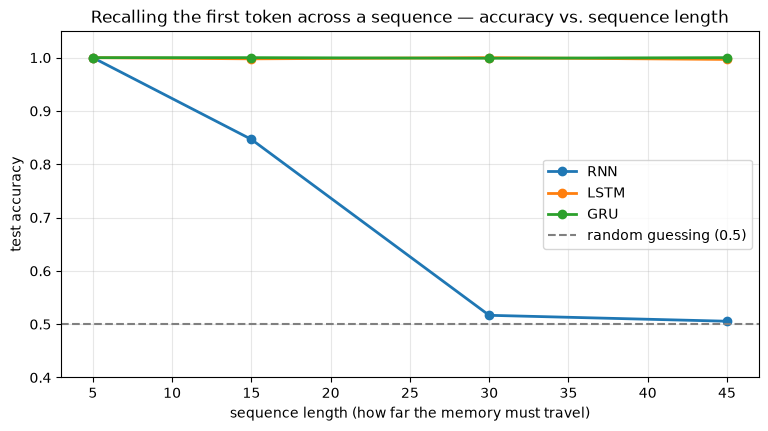

Read the plot: the vanilla RNN degrades as length grows; LSTM & GRU hold their memory.
(Exact numbers vary by random seed, but the trend is robust and is the whole point.)


In [21]:
plt.figure(figsize=(9, 4.5))
for kind, accs in results.items():
    plt.plot(lengths, accs, marker="o", lw=2, label=kind)
plt.axhline(0.5, color="gray", ls="--", label="random guessing (0.5)")
plt.title("Recalling the first token across a sequence — accuracy vs. sequence length")
plt.xlabel("sequence length (how far the memory must travel)")
plt.ylabel("test accuracy"); plt.ylim(0.4, 1.05); plt.legend(); plt.grid(alpha=0.3); plt.show()

print("Read the plot: the vanilla RNN degrades as length grows; LSTM & GRU hold their memory.")
print("(Exact numbers vary by random seed, but the trend is robust and is the whole point.)")

## 6. Which one should I use? A practical guide

| Situation | Recommended | Why |
|---|---|---|
| Short sequences (< ~10 steps), simple patterns | RNN is fine | cheap; no long-memory needed |
| Long-range dependencies, plenty of data | **LSTM** | most expressive gating, strong default |
| Long-range but limited data / want speed | **GRU** | fewer parameters, trains faster, ~equal accuracy |
| Not sure | **try GRU first, then LSTM** | GRU is a great, efficient default |

**A few real-world tips you'll actually use:**

- **Start with GRU or LSTM by default** for anything nontrivial — vanilla RNNs are mostly a
  teaching tool now.
- **Stack layers** (`num_layers=2`) and add **`dropout`** for more capacity/regularization.
- Use **`bidirectional=True`** when the *whole* sequence is available at once (e.g. classifying a
  finished sentence or a recorded signal) — it reads the sequence both forwards and backwards.
  **Do not** use it for real-time forecasting, where the future isn't known yet.
- **Where is "attention" / Transformers?** For very long sequences and large-scale NLP,
  Transformers have largely replaced RNNs. But **for streaming sensor data, low-latency
  edge/embedded deployment, and small-to-medium datasets, GRU/LSTM remain the practical
  state-of-the-art** — which is exactly the setting of our energy-forecasting capstone (notebook 06).

In [22]:
# The one-word swaps in action, plus the two most useful upgrades:
examples = {
    "vanilla RNN"          : nn.RNN(1, 16, batch_first=True),
    "LSTM"                 : nn.LSTM(1, 16, batch_first=True),
    "GRU"                  : nn.GRU(1, 16, batch_first=True),
    "2-layer LSTM+dropout" : nn.LSTM(1, 16, num_layers=2, dropout=0.2, batch_first=True),
    "bidirectional GRU"    : nn.GRU(1, 16, bidirectional=True, batch_first=True),
}
for name, layer in examples.items():
    n_params = sum(p.numel() for p in layer.parameters())
    print(f"{name:24s} -> {n_params:5d} trainable parameters")
print("\nNotice: LSTM has ~4x the gate machinery of a vanilla RNN; GRU sits in between.")

vanilla RNN              ->   304 trainable parameters
LSTM                     ->  1216 trainable parameters
GRU                      ->   912 trainable parameters
2-layer LSTM+dropout     ->  3392 trainable parameters
bidirectional GRU        ->  1824 trainable parameters

Notice: LSTM has ~4x the gate machinery of a vanilla RNN; GRU sits in between.


## 📚 Extra A · What is a *layer*? Stacking RNNs (`num_layers`)

Section 6 mentions `num_layers=2` and `bidirectional=True` only as quick tips — and they reappear
in notebooks 04–06 — so let's actually **understand and *see*** them.

**One layer = one recurrent cell** (RNN/LSTM/GRU) sweeping across the sequence, emitting a hidden
state at every time step. That whole sequence of hidden states `[h_1, …, h_T]` is the layer's
**output** (`h_out` in PyTorch).

**Stacking** (`num_layers=2`, a *deep* RNN) feeds the **output sequence of layer 1 in as the input
sequence of layer 2**:

```
 x_1  x_2  x_3  x_4           input sequence
  │    │    │    │
  ▼    ▼    ▼    ▼
[====== Layer 1 ======] →  h¹_1 h¹_2 h¹_3 h¹_4     (layer-1 hidden states)
  │    │    │    │          ...fed UP as layer-2 inputs
  ▼    ▼    ▼    ▼
[====== Layer 2 ======] →  h²_1 h²_2 h²_3 h²_4
                                         │
                                         ▼   final state → prediction
```

- **Function:** exactly like stacking convolutional layers in a CNN — **layer 1 learns short,
  low-level patterns; layer 2 composes them into higher-level abstractions.** More depth = more
  representational capacity.
- **Width vs. depth — two different knobs:** `hidden_size` = how *wide* each layer is;
  `num_layers` = how *deep* the stack is.
- **`dropout=` between layers:** randomly zeroes some of layer-1's outputs during training, as
  regularization. ⚠️ In PyTorch it is applied **only *between* stacked layers**, so it does nothing
  at all unless `num_layers > 1` — a classic silent no-op.
- **Cost:** more parameters, slower, easier to overfit. Depth helps most when the task has
  *hierarchical* structure (language, complex signals); it often does **little** for a simple task
  — which we'll confirm empirically in **Extra C**.

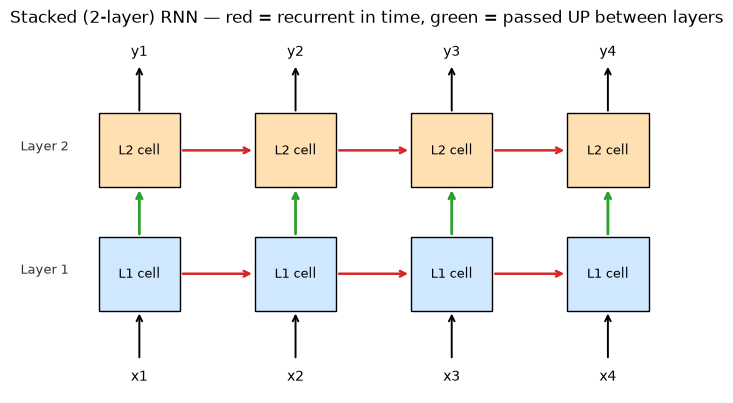

In [23]:
# Visualize a 2-layer (stacked) RNN unrolled: layer-1 outputs feed UP into layer 2 (green arrows).
import matplotlib.pyplot as plt

def draw_stacked(n_steps=4):
    fig, ax = plt.subplots(figsize=(2.3 * n_steps, 4.7))
    ys = {1: 1.0, 2: 2.5}
    colors = {1: "#cfe8ff", 2: "#ffe0b3"}
    for t in range(n_steps):
        x = t * 2.3
        for L in (1, 2):
            y = ys[L]
            ax.add_patch(plt.Rectangle((x, y), 1.2, 0.9, color=colors[L], ec="black"))
            ax.text(x + 0.6, y + 0.45, f"L{L} cell", ha="center", va="center", fontsize=9)
            if t < n_steps - 1:      # recurrent (horizontal) arrow within each layer
                ax.annotate("", xy=(x + 2.3, y + 0.45), xytext=(x + 1.2, y + 0.45),
                            arrowprops=dict(arrowstyle="->", lw=1.8, color="#d62728"))
        ax.annotate("", xy=(x + 0.6, 1.0), xytext=(x + 0.6, 0.4),      # input -> layer 1
                    arrowprops=dict(arrowstyle="->", lw=1.4))
        ax.text(x + 0.6, 0.15, f"x{t+1}", ha="center", fontsize=10)
        ax.annotate("", xy=(x + 0.6, 2.5), xytext=(x + 0.6, 1.9),      # layer 1 -> layer 2 (UP)
                    arrowprops=dict(arrowstyle="->", lw=2.0, color="#2ca02c"))
        ax.annotate("", xy=(x + 0.6, 4.0), xytext=(x + 0.6, 3.4),      # layer 2 -> output
                    arrowprops=dict(arrowstyle="->", lw=1.4))
        ax.text(x + 0.6, 4.1, f"y{t+1}", ha="center", fontsize=10)
    ax.text(-1.15, 1.45, "Layer 1", color="#333", fontsize=9)
    ax.text(-1.15, 2.95, "Layer 2", color="#333", fontsize=9)
    ax.set_xlim(-1.3, 2.3 * n_steps); ax.set_ylim(0, 4.4); ax.axis("off")
    ax.set_title("Stacked (2-layer) RNN — red = recurrent in time, green = passed UP between layers")
    plt.show()

draw_stacked()

In [24]:
# How `num_layers` changes the tensors coming out of an RNN.
print("STACKING — tensor shapes vs. num_layers (input: batch=1, time=5, features=2):\n")
for nl in [1, 2, 3]:
    g = nn.GRU(2, 8, num_layers=nl, batch_first=True)
    h_out, h_n = g(torch.randn(1, 5, 2))
    print(f"  num_layers={nl}:  h_out {tuple(h_out.shape)}  (ONLY the top layer, every time step)"
          f"   |   h_n {tuple(h_n.shape)}  (final state of EACH layer)")
print("\nKey: `h_out` always carries the TOP layer's states only; `h_n`'s first dim counts layers.")
print("For a many-to-one head you still use h_out[:, -1, :] (the top layer's last step).")

STACKING — tensor shapes vs. num_layers (input: batch=1, time=5, features=2):

  num_layers=1:  h_out (1, 5, 8)  (ONLY the top layer, every time step)   |   h_n (1, 1, 8)  (final state of EACH layer)
  num_layers=2:  h_out (1, 5, 8)  (ONLY the top layer, every time step)   |   h_n (2, 1, 8)  (final state of EACH layer)
  num_layers=3:  h_out (1, 5, 8)  (ONLY the top layer, every time step)   |   h_n (3, 1, 8)  (final state of EACH layer)

Key: `h_out` always carries the TOP layer's states only; `h_n`'s first dim counts layers.
For a many-to-one head you still use h_out[:, -1, :] (the top layer's last step).


## 📚 Extra B · Bidirectional RNNs

A **bidirectional** RNN runs **two** RNNs over the sequence and glues them together:

- a **forward** pass (t = 1 → T): each position sees the **past**,
- a **backward** pass (t = T → 1): each position sees the **future**,
- the output at each step is the **concatenation** `[forward_h ; backward_h]` → **`2 × hidden`** wide.

```
forward  →→→→→→→→→→→→   (left-to-right: sees the past)
backward ←←←←←←←←←←←←   (right-to-left: sees the future)
output_t = [ forward_h_t ; backward_h_t ]      (concatenated → 2 × hidden)
```

- **Function:** every position gets context from **both sides**. Essential when meaning depends on
  what comes *after* — e.g. tagging "good" in *"the movie was **not** good"* needs the right context.
- **✅ Use it when the *whole* sequence is available at once:** text / signal **classification**
  (notebook 04), sequence tagging / NER, encoding a finished recording.
- **🚫 Never use it for forecasting, streaming, or autoregressive generation** (notebooks 05, 06, 08):
  the "future" doesn't exist yet at inference, so a backward pass would be **look-ahead leakage**.
  That's precisely why every forecasting/generation model in this series is *unidirectional*.
- **Shape gotcha:** the output width **doubles** to `2 × hidden`, so any layer you attach after a
  bidirectional RNN must expect `2 * hidden` inputs.

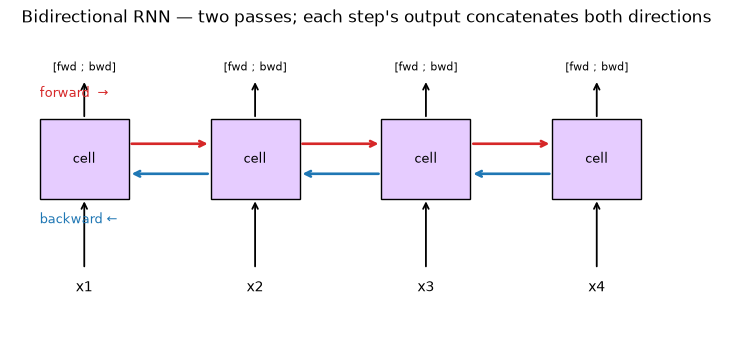

In [25]:
# Visualize a bidirectional RNN: a forward pass (red) AND a backward pass (blue); outputs concat.
def draw_bidir(n_steps=4):
    fig, ax = plt.subplots(figsize=(2.3 * n_steps, 3.9))
    y = 1.5
    for t in range(n_steps):
        x = t * 2.3
        ax.add_patch(plt.Rectangle((x, y), 1.2, 0.9, color="#e6ccff", ec="black"))
        ax.text(x + 0.6, y + 0.45, "cell", ha="center", va="center", fontsize=9)
        ax.annotate("", xy=(x + 0.6, y), xytext=(x + 0.6, 0.7),
                    arrowprops=dict(arrowstyle="->", lw=1.3))
        ax.text(x + 0.6, 0.45, f"x{t+1}", ha="center", fontsize=10)
        ax.annotate("", xy=(x + 0.6, y + 1.35), xytext=(x + 0.6, y + 0.9),
                    arrowprops=dict(arrowstyle="->", lw=1.3))
        ax.text(x + 0.6, y + 1.45, "[fwd ; bwd]", ha="center", fontsize=8)
    for t in range(n_steps - 1):      # forward (red, top) and backward (blue, bottom) arrows
        x = t * 2.3
        ax.annotate("", xy=(x + 2.3, y + 0.62), xytext=(x + 1.2, y + 0.62),
                    arrowprops=dict(arrowstyle="->", lw=1.9, color="#d62728"))
        ax.annotate("", xy=(x + 1.2, y + 0.28), xytext=(x + 2.3, y + 0.28),
                    arrowprops=dict(arrowstyle="->", lw=1.9, color="#1f77b4"))
    ax.text(0.0, y + 1.15, "forward  →", color="#d62728", fontsize=9)
    ax.text(0.0, y - 0.28, "backward ←", color="#1f77b4", fontsize=9)
    ax.set_xlim(-0.4, 2.3 * n_steps); ax.set_ylim(0, y + 1.9); ax.axis("off")
    ax.set_title("Bidirectional RNN — two passes; each step's output concatenates both directions")
    plt.show()

draw_bidir()

### How bidirectional RNNs work — the weights, the maths, and the two passes

A bidirectional layer is literally **two independent RNNs, each with its own weights** (nothing is
shared):

- a **forward** RNN with weights $\{W_{ih}^{f},\, W_{hh}^{f},\, b^{f}\}$,
- a **backward** RNN with *different* weights $\{W_{ih}^{b},\, W_{hh}^{b},\, b^{b}\}$.

Both read the **same input sequence** $x_1,\dots,x_T$ — just in opposite orders.

**Forward pass** (sweeps $t = 1 \to T$, accumulating the *past*):
$$h^{f}_t = \tanh\!\big(W_{ih}^{f}\, x_t \;+\; W_{hh}^{f}\, h^{f}_{t-1} \;+\; b^{f}\big)$$

**Backward pass** (sweeps $t = T \to 1$, accumulating the *future*):
$$h^{b}_t = \tanh\!\big(W_{ih}^{b}\, x_t \;+\; W_{hh}^{b}\, h^{b}_{t+1} \;+\; b^{b}\big)$$

Read those two lines carefully — three things to notice:

1. **The input is multiplied by a weight *matrix*, not by the hidden state.** Each step adds two
   matrix–vector products: $W_{ih}\, x_t$ (input × input-weights) **plus**
   $W_{hh}\, h_{\text{neighbour}}$ (neighbour's hidden × recurrent-weights). It is never "input ×
   hidden".
2. **The same $x_t$ enters both passes, but with different weights.** The forward pass multiplies it
   by $W_{ih}^{f}$; the backward pass by its own, separate $W_{ih}^{b}$.
3. **A different neighbour feeds in.** The forward step uses $h^{f}_{t-1}$ (from the *past*); the
   backward step uses $h^{b}_{t+1}$ (from the *future*). That single index — $t-1$ vs $t+1$ — is the
   entire difference between the two directions.

**They are not "first pass, then a later second pass" in time** — they are two *independent* sweeps
(a GPU runs them in parallel). What differs is *what each has seen* when it reaches position $t$:

| at position $t$ | has read | fully informed at |
|---|---|---|
| forward $h^{f}_t$ | $x_1, \dots, x_t$ | the **end** ($t = T$) |
| backward $h^{b}_t$ | $x_T, \dots, x_t$ | the **start** ($t = 0$) |

Finally, the layer **concatenates the two, per position**:
$$\text{h}_{out_t} = \big[\, h^{f}_t \;;\; h^{b}_t \,\big] \quad\Rightarrow\quad \text{width } 2 \times \text{hidden}.$$

That is exactly why the many-to-one readout in **Extra C** takes the forward summary from the
**last** step and the backward summary from the **first** step:

```python
fwd = h_out[:, -1, :hidden]   # forward:  fully informed at the END
bwd = h_out[:,  0, hidden:]   # backward: fully informed at the START (t = 0)
feat = torch.cat([fwd, bwd], dim=1)
```

On the recall task, the backward sweep reaching $t = 0$ has just read the **cued first token** —
which is why the bidirectional model scores ~100% where the forward-only RNN is stuck at chance.

In [26]:
# See it for yourself: a bidirectional RNN holds TWO separate weight sets (nothing shared).
bi = nn.RNN(input_size=2, hidden_size=5, batch_first=True, bidirectional=True)
print("Parameters of a bidirectional RNN (input=2, hidden=5):\n")
for name, p in bi.named_parameters():
    which = "BACKWARD pass (its own W)" if name.endswith("_reverse") else "forward pass"
    print(f"  {name:22s} {str(tuple(p.shape)):9s} -> {which}")
print("\nThe '_reverse' params are the backward RNN's OWN W_ih / W_hh / biases.")
print("W_ih maps the input (2 -> 5); W_hh maps the previous hidden state (5 -> 5).")
print("Same input x_t goes to both directions; each multiplies it by its own W_ih.")

Parameters of a bidirectional RNN (input=2, hidden=5):

  weight_ih_l0           (5, 2)    -> forward pass
  weight_hh_l0           (5, 5)    -> forward pass
  bias_ih_l0             (5,)      -> forward pass
  bias_hh_l0             (5,)      -> forward pass
  weight_ih_l0_reverse   (5, 2)    -> BACKWARD pass (its own W)
  weight_hh_l0_reverse   (5, 5)    -> BACKWARD pass (its own W)
  bias_ih_l0_reverse     (5,)      -> BACKWARD pass (its own W)
  bias_hh_l0_reverse     (5,)      -> BACKWARD pass (its own W)

The '_reverse' params are the backward RNN's OWN W_ih / W_hh / biases.
W_ih maps the input (2 -> 5); W_hh maps the previous hidden state (5 -> 5).
Same input x_t goes to both directions; each multiplies it by its own W_ih.


In [27]:
# How bidirectionality changes the tensors.
print("BIDIRECTIONAL — tensor shapes (input: batch=1, time=5, features=2, hidden=8):\n")
uni = nn.GRU(2, 8, batch_first=True)
bi  = nn.GRU(2, 8, batch_first=True, bidirectional=True)
ho1, h1 = uni(torch.randn(1, 5, 2))
ho2, h2 = bi(torch.randn(1, 5, 2))
print(f"  unidirectional:  h_out {tuple(ho1.shape)}   |   h_n {tuple(h1.shape)}")
print(f"  bidirectional :  h_out {tuple(ho2.shape)}   |   h_n {tuple(h2.shape)}")
print("\n`h_out` last dim DOUBLES to 2*hidden = [forward | backward] concatenated per step.")
print("`h_n` first dim doubles: rows are [layer0 forward, layer0 backward, ...].")
print("So a Linear head after a bidirectional RNN needs in_features = 2*hidden.")

BIDIRECTIONAL — tensor shapes (input: batch=1, time=5, features=2, hidden=8):

  unidirectional:  h_out (1, 5, 8)   |   h_n (1, 1, 8)
  bidirectional :  h_out (1, 5, 16)   |   h_n (2, 1, 8)

`h_out` last dim DOUBLES to 2*hidden = [forward | backward] concatenated per step.
`h_n` first dim doubles: rows are [layer0 forward, layer0 backward, ...].
So a Linear head after a bidirectional RNN needs in_features = 2*hidden.


## 📚 Extra C · Seeing it — a small empirical comparison

Let's *measure* the effect of **depth** (1 vs 2 layers) and **direction** (uni vs bidirectional),
reusing the **"recall the cued first token"** task from Section 2 at **length 40**.

Why this task is the perfect test:
- A **forward** RNN must **carry the first token across all 40 steps** to answer at the end — hard
  (the vanishing-gradient problem from Section 1).
- A **backward** pass reads that first token **last**, so it's fresh in memory — a bidirectional
  RNN should get it almost for free.

So we expect: unidirectional RNNs ≈ 50% (chance), extra depth ≈ no help, **bidirectional ≈ 100%**.

> ⚠️ Remember: bidirectional only "cheats" like this because the **whole sequence is available**.
> In a real forecast you can't peek at the future, so this trick is off-limits there (notebooks 06/08).

RNN 1 layer (uni)          recall accuracy @len40: 0.50
RNN 2 layers (uni)         recall accuracy @len40: 0.50
RNN bidirectional          recall accuracy @len40: 1.00


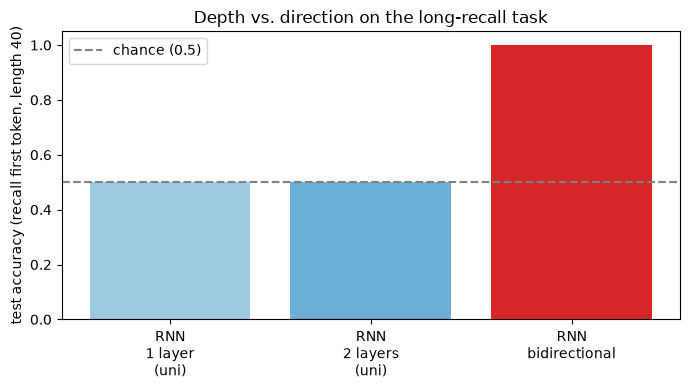

In [28]:
# A tiny model that toggles num_layers and bidirectional. Reuses make_memory_task from Section 2.
class DepthDirNet(nn.Module):
    def __init__(self, hidden=24, num_layers=1, bidirectional=False):
        super().__init__()
        self.rnn = nn.RNN(2, hidden, num_layers=num_layers, batch_first=True,
                          bidirectional=bidirectional)
        self.bi, self.hidden = bidirectional, hidden
        self.head = nn.Linear(hidden * (2 if bidirectional else 1), 2)   # 2*hidden if bidirectional

    def forward(self, x):
        h_out, _ = self.rnn(x)
        fwd = h_out[:, -1, :self.hidden]        # forward direction, has read the WHOLE sequence
        if self.bi:
            bwd = h_out[:, 0, self.hidden:]     # backward direction, ALSO read the whole seq (ends at t=0)
            feat = torch.cat([fwd, bwd], dim=1)
        else:
            feat = fwd
        return self.head(feat)

def quick_train_eval(builder, length=40, runs=3, epochs=35, bs=128):
    '''Average recall accuracy over a few runs (single runs are noisy).'''
    accs = []
    for _ in range(runs):
        Xtr, ytr = make_memory_task(600, length)
        Xte, yte = make_memory_task(300, length)
        Xtr, ytr, Xte, yte = Xtr.to(device), ytr.to(device), Xte.to(device), yte.to(device)
        m = builder().to(device)
        opt = torch.optim.Adam(m.parameters(), lr=5e-3)
        lossf = nn.CrossEntropyLoss()
        for _ in range(epochs):
            m.train(); perm = torch.randperm(len(Xtr))
            for i in range(0, len(Xtr), bs):
                idx = perm[i:i + bs]; opt.zero_grad()
                lossf(m(Xtr[idx]), ytr[idx]).backward()
                nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        m.eval()
        with torch.no_grad():
            accs.append((m(Xte).argmax(1) == yte).float().mean().item())
    return float(np.mean(accs))

configs = {
    "RNN\n1 layer\n(uni)":   lambda: DepthDirNet(num_layers=1),
    "RNN\n2 layers\n(uni)":  lambda: DepthDirNet(num_layers=2),
    "RNN\nbidirectional":    lambda: DepthDirNet(bidirectional=True),
}
scores = {name: quick_train_eval(b) for name, b in configs.items()}
for name, s in scores.items():
    print(f"{name.replace(chr(10), ' '):26s} recall accuracy @len40: {s:.2f}")

plt.figure(figsize=(7, 4))
plt.bar(range(len(scores)), list(scores.values()), color=["#9ecae1", "#6baed6", "#d62728"])
plt.xticks(range(len(scores)), list(scores.keys()))
plt.axhline(0.5, color="gray", ls="--", label="chance (0.5)")
plt.ylabel("test accuracy (recall first token, length 40)")
plt.title("Depth vs. direction on the long-recall task")
plt.legend(); plt.ylim(0, 1.05); plt.tight_layout(); plt.show()

### Takeaways

| Feature | What it does | Use it when… | Avoid when… |
|---|---|---|---|
| **Stacking** (`num_layers>1`) | deeper net → higher-level features | task has hierarchical structure; you have data | it just overfits / adds cost with no gain (like the simple task above) |
| **`dropout=`** | regularizes *between* stacked layers | `num_layers>1` and you see overfitting | `num_layers==1` (it's a no-op) |
| **Bidirectional** | reads the sequence both ways, `2×hidden` h_out | the **whole** sequence is known: classification, tagging | **forecasting / generation / streaming** (look-ahead leakage) |

In the bar chart, **depth alone didn't help** this simple recall task, but **bidirectionality solved
it** — because the backward pass reads the cued token last. Contrast with Section 5, where **gating
(LSTM/GRU) also solved it**, but *unidirectionally* — which is why gated units, not bidirectionality,
are the fix you can still use for real-time forecasting.

Where these show up later: **notebook 04** stacks 2 LSTM layers for classification (and *could* go
bidirectional, since the whole window is known); **notebooks 05, 06, 08** stay **unidirectional**
because they predict the future one step at a time.

## 7. Recap & what's next

- Vanilla RNNs **forget** because gradients **vanish** over long sequences.
- **LSTM** adds a protected **cell-state highway** and **three gates** (forget/input/output).
- **GRU** is a lighter version with **two gates** (reset/update) — usually as accurate, faster.
- We *proved* the difference: on a long-memory task, RNN accuracy collapses while LSTM/GRU hold.
- Swapping architectures in PyTorch is a **one-word change**, so always A/B test them.

You now have the full toolkit: RNN, LSTM, GRU, all the shapes, and the training loop. From here we
apply them to **consulting-style problems**.

➡️ **Next:** `04_many_to_one_classification.ipynb` — a realistic **sequence-classification** task
(classifying multivariate signal patterns), the workhorse "many-to-one" use case behind churn,
fraud, activity recognition, and fault detection.